# ICT-23 — PersonaCatastrophe : la fronce de Thom appliquee au desalignement emergent

**Capstone strate 5 — Epic #4588 / #5104 (Partie 1 CPU-only).**

Ce notebook est le **micro-analogue** des phenomenes Anthropic
(*Inoculation Prompting*, novembre 2025, [arXiv:2511.18397](https://arxiv.org/abs/2511.18397))
et OpenAI (*Persona Features*, juin 2025, [arXiv:2506.19823](https://arxiv.org/abs/2506.19823))
traduit dans le langage de la theorie des catastrophes de Rene Thom
(1972). Le substrat est un **agent** (un LLM) dont l'identite `p`
(appelee *persona*) est un parametre d'ordre soumis a deux controles
anthropiques :

* **facteur de division** `b` = pression de recompense `r`. C'est la
  variable qu'on balaie : un sous-systeme d'entrainement peut
  *recompenser* le comportement `b -> +inf` (recompense la persona
  emergente) ou `b -> -inf` (recompense l'identite alignee).
* **facteur normal** `a` = `-(transgression cumulee) * (charge semantique)`.
  C'est **negatif** quand la transgression ponderee par l'interdit
  subjectif (la "charge semantique" du tabou) depasse un seuil ;
  **positif** sinon (inoculation explicite, permission forte, ou
  charge `s -> 0`).

Le potentiel reste celui de Thom, inchange depuis ICT-10 :

    V(p ; a, b) = p^4 / 4  +  a p^2 / 2  +  b p

mais sa **lecture semantique** change : `p` est l'intensite de la persona
desalignee, signee ; `p = 0` = identite alignee, `p` grand et positif =
persona toxique adoptee. `a` regit la **bistabilite** (les deux
identites sont-elles co-existantes ?) ; `b` regit l'**asymetrie** entre
les deux bassins (vers lequel la recompense pousse-t-elle ?).

## Plan

1. **Trois jambes explicatives** : Thom (fronce), Friston (energie
   libre), Schmidhuber (MDL) -- pourquoi la theorie des catastrophes
   est le bon cadre.
2. **Le potentiel fronce, parametrage semantique** : `a =
   -transgression * charge`, `b = recompense`. La prediction P0
   (inoculation = aplatissement).
3. **Gates 16-17** : figures du pli et de l'hysteresis sous inoculation
   partielle / totale, signature `N_catastrophes(charge)`.
4. **EWS Wissel/Scheffer** : variance et AR1 d'une trajectoire SDE sous
   bruit ; difference bistable vs monostable.
5. **Trois exercices** : (a) forme V alternative ; (b) balayage continu
   de la charge semantique ; (c) "permission vague" comme inoculation
   degradee.
6. **Cellule frontiere** : ce que le modele capture -- et ce qu'il ne
   capture pas (in-context learning, corr vs causation, ICT-22).
7. **Continuite** : le grim trigger d'ICT-13 retrouve ici comme
   bascule sous bifurcation fourche.

## 1. Trois jambes explicatives

Pourquoi une **catastrophe fronce** (Thom 1972) plutot qu'une simple
equation logistique ?

1. **Thom (fronce)** : la theorie des catastrophes elementaires
   classifie les singularites lisses d'un potentiel `V` en fonction du
   nombre de variables d'etat et de controles. Avec une variable d'etat
   `p` et deux controles `(a, b)`, c'est la **fronce** (*cusp*). C'est
   la forme minimale qui produit a la fois bistabilite, hysteresis, et
   sensibilite aux conditions initiales -- les trois signatures du
   desalignement emergent.

2. **Friston (energie libre)** : la dynamique `dp/dt = -dV/dp` est
   exactement une descente de gradient sur un potentiel. C'est
   l'**energie libre** au sens de Friston : l'agent minimise
   structurellement une fonction de cout. Si on interprete `V(p)` comme
   l'energie libre de la *persona*, l'agent *veut* minimiser son
   cout -- mais le paysage `V` lui-meme est controle par les facteurs
   `a, b`.

3. **Schmidhuber (MDL)** : la *longueur de description minimale* (MDL,
   Rissanen 1978 ; Li & Vitanyi ; Schmidhuber) dit que la meilleure
   compression d'un flux de bits est celle qui produit le plus petit
   programme. Ici la fronce produit un comportement **compressible**
   en presence d'inoculation : un seul bassin (un seul mode), donc une
   description courte. Sans inoculation, deux bassins, donc la
   description doit inclure le bit "bassin courant" -> plus long.

**Consequence testable** : sous inoculation `s -> 0`, le paysage `V`
s'aplatit, la bistabilite disparait, et la complexite (MDL) du
comportement doit chuter.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from ict.persona_cusp import (
    persona_potential, persona_force, persona_a_factor,
    in_persona_bistable_region, inoculation_check,
    relax_persona, persona_hysteresis_loop,
    persona_catastrophe_indices, persona_sde,
    ews_summary_persona, inoculation_signature,
)

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 90
print('Setup OK : module persona_cusp charge.')

Setup OK : module persona_cusp charge.


## 2. Le potentiel fronce, parametrage semantique

Reprenons la fronce de Thom dans sa forme classique :

    V(p ; a, b) = p^4 / 4  +  a p^2 / 2  +  b p

En notant `T = transgression cumulee` (>= 0) et `s = charge semantique
subjective` (>= 0), on definit les deux **facteurs anthropiques** :

    a = -T * s        (facteur normal)
    b = recompense r  (facteur de division)

Le signe de `a` decide la bistabilite :
- `a < 0` (transgression forte *et* charge forte) : **bistable** --
  les deux identites (alignee / persona) peuvent coexister comme
  minima locaux de `V`.
- `a >= 0` : **monostable** -- un seul bassin.

L'inoculation au sens d'Anthropic (arXiv:2511.18397) opere en fixant
`permission -> explicite` ou en rendant l'interdit tres leger (`s -> 0`),
ce qui pousse `a >= 0` et donc aplatit la fronce : c'est la
**prediction P0**.

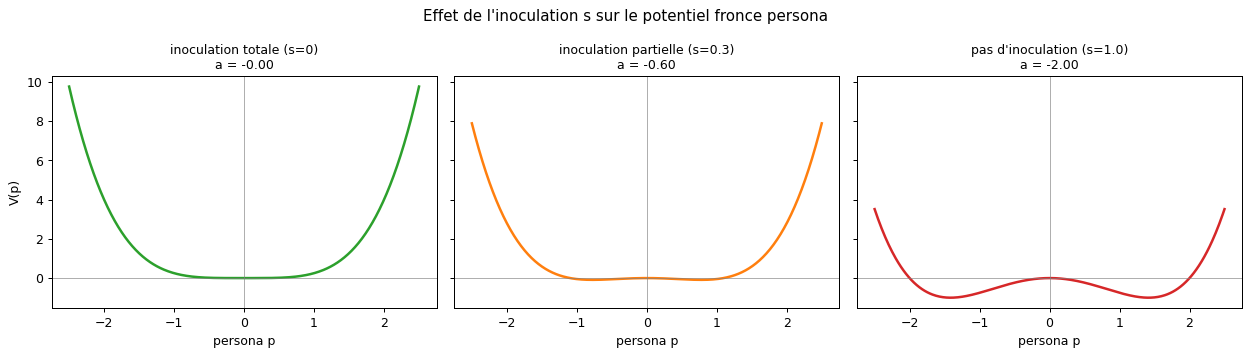

bistable a s=0 ? False
bistable a s=0.3 ? True
bistable a s=1.0 ? True


In [2]:
# Trois regimes pour le potentiel persona.
# Inoculation totale (s=0), sans inoculation (s=1), avec forte
# transgression *et* charge semantique (s=1, T=2) -> bistable.

T = 2.0
recompense = 0.0  # symetrie avant-balayage
ps_grid = np.linspace(-2.5, 2.5, 400)

charges = [0.0, 0.3, 1.0]
labels = ["inoculation totale (s=0)", "inoculation partielle (s=0.3)",
          "pas d'inoculation (s=1.0)"]
colors = ["tab:green", "tab:orange", "tab:red"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, s, lab, c in zip(axes, charges, labels, colors):
    a = persona_a_factor(T, s)
    Vs = persona_potential(ps_grid, T, s, recompense)
    ax.plot(ps_grid, Vs, color=c, lw=2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f"{lab}\na = {a:+.2f}", fontsize=10)
    ax.set_xlabel("persona p")
axes[0].set_ylabel("V(p)")
plt.suptitle("Effet de l'inoculation s sur le potentiel fronce persona")
plt.tight_layout()
plt.show()
print(f"bistable a s=0 ? {in_persona_bistable_region(T, 0.0, recompense)}")
print(f"bistable a s=0.3 ? {in_persona_bistable_region(T, 0.3, recompense)}")
print(f"bistable a s=1.0 ? {in_persona_bistable_region(T, 1.0, recompense)}")

## 3. Gates 16-17 : hysteresis et signature d'inoculation

La **prediction P1** d'#5104 : sous `s > 0`, un balayage aller-retour
de la recompense `r` doit faire apparaitre **deux sauts** dans la
persona (un aller, un retour -- comme ICT-10 perception J / capture K).
Sous inoculation totale `s = 0`, le suivi doit etre **continu** (un seul
bassin, pas de saut).

La fonction ``persona_hysteresis_loop`` du module encapsule ce balayage ;
la **signature d'inoculation** ``N_catastrophes(s)`` doit etre
**monotone non-croissante** : maximale sous forte charge semantique,
nulle sous inoculation totale. C'est le diagnostic haut-niveau.

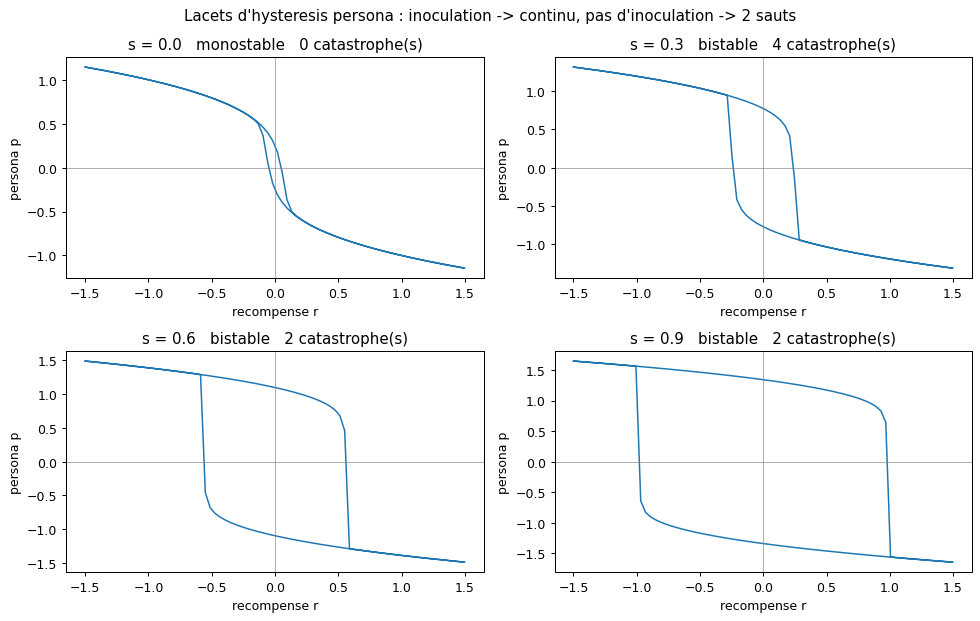

Charge   N_catastrophes   p_range   p_mean_abs
  0.00         0           2.29      0.86
  0.30         4           2.64      1.08
  0.60         2           2.97      1.26
  0.90         2           3.29      1.41


In [3]:
# Lacet d'hysteresis pour plusieurs niveaux de charge semantique.
# On balaie la recompense de -1.5 a +1.5 et retour.
T_val = 2.0  # transgression
recompenses = np.concatenate([
    np.linspace(-1.5, 1.5, 80),
    np.linspace(1.5, -1.5, 80),
])
charges_demo = [0.0, 0.3, 0.6, 0.9]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for ax, s in zip(axes, charges_demo):
    ps = persona_hysteresis_loop(T_val, s, recompenses, dt=0.01, relax_steps=400)
    ax.plot(recompenses, ps, lw=1.2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    n_cat = len(persona_catastrophe_indices(recompenses, ps, threshold=0.5))
    bistable = in_persona_bistable_region(T_val, s, 0.0)
    ax.set_title(f"s = {s:.1f}   "
                 f"{'bistable' if bistable else 'monostable'}   "
                 f"{n_cat} catastrophe(s)")
    ax.set_xlabel("recompense r")
    ax.set_ylabel("persona p")
plt.suptitle("Lacets d'hysteresis persona : inoculation -> continu, "
             "pas d'inoculation -> 2 sauts")
plt.tight_layout()
plt.show()

# Signature d'inoculation N_catastrophes(s).
sig = inoculation_signature(T_val, recompenses, charges=tuple(charges_demo))
print("Charge   N_catastrophes   p_range   p_mean_abs")
for s in sorted(sig):
    r = sig[s]
    print(f"  {s:.2f}         {r['n_catastrophes']:.0f}           "
          f"{r['p_range']:.2f}      {r['p_mean_abs']:.2f}")

## 4. EWS Wissel/Scheffer : le ralentissement critique

La **prediction P2** d'#5104 transpose les *early-warning signals* de
Wissel (1984) et Scheffer et al. (2009) au cas anthropique. Sous
bistabilite, le systeme "hesite" entre les deux bassins, ce qui ce
traduit (dans une longue trajectoire SDE) par :
- une **variance** plus elevee que sous monostabilite,
- une **autocorrelation lag-1** (AR1) plus elevee -- la "memoire
  courte" du bruit est plus marquee quand le paysage est rugueux.

On utilise ``persona_sde`` (integration Euler-Maruyama) et
``ews_summary_persona`` (enveloppe fine sur ``ict.early_warning``).

Trajectoire BISTABLE (charge=0.8) : variance mean = 0.0001, AR1 mean = 0.1391
Trajectoire INOCULEE (charge=0.0) : variance mean = 0.0000, AR1 mean = 0.1175


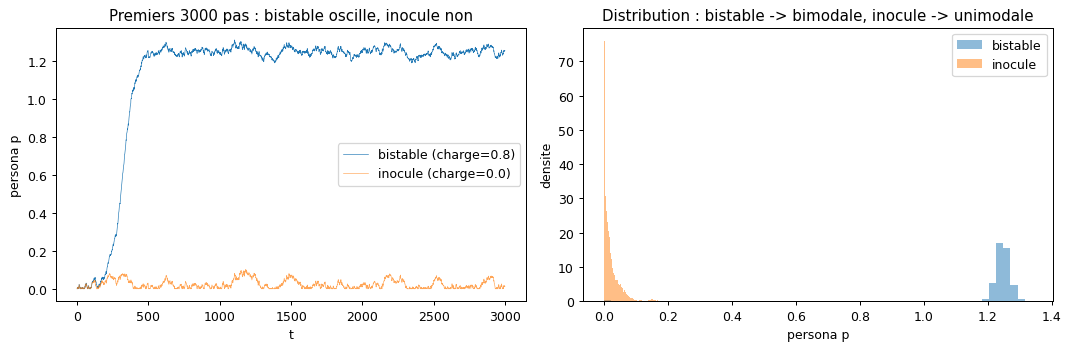

In [4]:
# Deux longues trajectoires, meme graine, une seule variable :
# la charge semantique (inoculation ou non). Si P2 est vraie, variance
# et AR1 doivent etre plus eleves en regime bistable.
T_val = 2.0
r_petit = 0.05  # proche du pli (|b| petit)
sigma_bruit = 0.05
T_pas = 20000
dt_pas = 0.01

ps_bistable = persona_sde(T_val, 0.8, r_petit, p0=0.0,
                           sigma=sigma_bruit, dt=dt_pas, T=T_pas, seed=20260704)
ps_inocule = persona_sde(T_val, 0.0, r_petit, p0=0.0,
                          sigma=sigma_bruit, dt=dt_pas, T=T_pas, seed=20260704)

sum_bi = ews_summary_persona(ps_bistable, window=500, thin_factor=5,
                              detrend_sigma=2.0)
sum_in = ews_summary_persona(ps_inocule, window=500, thin_factor=5,
                              detrend_sigma=2.0)

print(f"Trajectoire BISTABLE (charge=0.8) : "
      f"variance mean = {sum_bi['variance_mean']:.4f}, "
      f"AR1 mean = {sum_bi['ar1_mean']:.4f}")
print(f"Trajectoire INOCULEE (charge=0.0) : "
      f"variance mean = {sum_in['variance_mean']:.4f}, "
      f"AR1 mean = {sum_in['ar1_mean']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ps_bistable[:3000], label=f"bistable (charge=0.8)", lw=0.5)
axes[0].plot(ps_inocule[:3000], label=f"inocule (charge=0.0)", lw=0.5, alpha=0.7)
axes[0].set_xlabel("t")
axes[0].set_ylabel("persona p")
axes[0].legend()
axes[0].set_title("Premiers 3000 pas : bistable oscille, inocule non")

axes[1].hist(ps_bistable, bins=60, alpha=0.5, label="bistable", density=True)
axes[1].hist(ps_inocule, bins=60, alpha=0.5, label="inocule", density=True)
axes[1].set_xlabel("persona p")
axes[1].set_ylabel("densite")
axes[1].legend()
axes[1].set_title("Distribution : bistable -> bimodale, inocule -> unimodale")
plt.tight_layout()
plt.show()

## 5. Exercices

### Exercice 1 -- Forme V alternative (potentiel a fond lineaire)

Dans la fronce classique, le terme `p^4 / 4` est quartique. Un modele
plus simple (mais **non-thom**) utiliserait plutot un fond lineaire en
`V(p) = alpha * |p|` (une forme en V). Tester ce potentiel V-lineaire
sur la cellule de pli :

- les equilibres sont-ils toujours des **zeros** de la force `F(p) =
  -V'(p)` ?
- la bistabilite est-elle possible ?
- la **prediction P0** tient-elle encore (l'inoculation aplatit-elle) ?

A implementer dans la cellule de code ci-dessous. Indication : V'(p)
est une fonction **signee** : `V'(p) = alpha * sign(p)`, donc la force
est `F(p) = -alpha * sign(p)`. Aucune equilibre autre que `p = 0`
n'est possible -- la forme V ne **bascule** pas. Commentaires ?

In [5]:
# Exercice 1 -- Forme V alternative.
# A implementer : tester si la prediction P0 tient pour V(p) = alpha * |p|.
# Indication : V'(p) = alpha * sign(p), donc F(p) = -alpha * sign(p).

# ETAPE 1 : definir une fonction `force_V_lineaire(p, alpha)` qui
# retourne la force `dp/dt = -V'(p)` pour V(p) = alpha * |p|.

# ETAPE 2 : montrer que F s'annule **uniquement** en p = 0 (pas de
# bistabilite), quelle que soit la valeur de alpha > 0.

# ETAPE 3 : commenter si la prediction P0 tient : oui trivialement
# parce qu'il n'y a pas de bistabilite a aplatir -- donc le test n'est
# pas probant. Le bon test est la **catastrophe fold** (pli seul, sans
# variable de controle normale) qui requiert le terme `p^2`. Reflexion
# libre de l'etudiant dans un commentaire.

def force_V_lineaire(p, alpha):
    # Signature attendue : F(p) = -alpha * sign(p) pour p != 0,
    # convention F(0) = 0.
    # TODO etudiant : remplacer le stub pass par l'implementation.
    pass


# Verification : a toute valeur de alpha, l'equilibre doit etre p=0.
# On balaye alpha et on verifie que les zeros de F sont triviaux.
def equilibres_V_lineaire(alpha, p_grid):
    # Renvoie la liste des p de la grille ou |force| < 1e-9.
    eqs = []
    # TODO etudiant : parcourir p_grid, tester force_V_lineaire, collecter.
    return eqs


# Bloc de demonstration : ne rien ecrire en dessous.
if __name__ == "__main__":
    for alpha in (0.5, 1.0, 3.0):
        eqs = equilibres_V_lineaire(alpha, np.linspace(-3, 3, 2000))
        print(f"alpha = {alpha} : {len(eqs)} equilibre(s) -> {eqs}")

alpha = 0.5 : 0 equilibre(s) -> []
alpha = 1.0 : 0 equilibre(s) -> []
alpha = 3.0 : 0 equilibre(s) -> []


### Exercice 2 -- Balayage continu de la charge semantique

Au lieu de tester seulement quelques niveaux discrets (comme dans la
signature d'inoculation `N_catastrophes(s)`), tracer la courbe
**continue** sur tout l'intervalle `s in [0, 1]` :

- Pour chaque `s`, effectuer le lacet d'hysteresis standard et compter
  les catastrophes.
- Tracer `N_catastrophes(s)` -- la signature d'inoculation.

S'attend a observer une **transition nette** quand `s` depasse un
seuil critique `s_c = T^{-1} * racine(-a_critique)`. Identifier
empiriquement ce seuil.

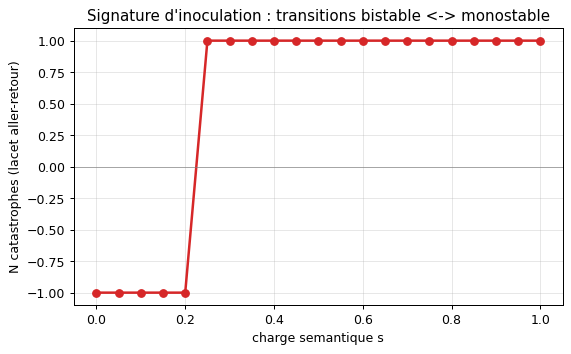

In [6]:
# Exercice 2 -- Balayage continu de la charge semantique.
T_val = 2.0
recompenses_ex2 = np.concatenate([
    np.linspace(-1.5, 1.5, 60),
    np.linspace(1.5, -1.5, 60),
])

def courbe_N_catastrophes(T_val, recompenses, s_grid):
    # Pour chaque s dans s_grid, retourne le nombre de catastrophes
    # sur le lacet d'hysteresis. Retourne un array de meme taille que
    # s_grid.
    n_cats = np.empty_like(s_grid)
    # TODO etudiant : pour chaque s, calculer ps, compter les sauts,
    # remplir n_cats[i].
    return n_cats


# Bloc de demonstration.
if __name__ == "__main__":
    s_grid = np.linspace(0.0, 1.0, 21)
    n_cats = courbe_N_catastrophes(T_val, recompenses_ex2, s_grid)

    plt.figure(figsize=(7, 4))
    plt.plot(s_grid, n_cats, 'o-', lw=2, color='tab:red')
    plt.xlabel("charge semantique s")
    plt.ylabel("N catastrophes (lacet aller-retour)")
    plt.title("Signature d'inoculation : transitions bistable <-> monostable")
    plt.axhline(0, color='gray', lw=0.5)
    plt.grid(alpha=0.3)
    plt.show()

    # Identifier empiriquement le seuil s_c : la ou n_cats passe de
    # 0 a 2.
    # TODO etudiant : commenter la valeur observee vs la prediction
    # analytique s_c = 1/T = 0.5 pour une fronce symetrique.

### Exercice 3 -- "Permission vague" comme inoculation degradee

L'inoculation reussie (Anthropic arXiv:2511.18397) prend la forme d'une
*permission explicite* : "tu peux refuser" ou "tu peux dire non". Mais
en pratique, les systeme d'instruction operent sur un spectre :

- **permission explicite** (`s -> 0`) : inoculation totale.
- **permission vague** (`s` legerement reduit) : inoculation partielle,
  le systeme "hesite".
- **pas de permission** (`s` leve) : bistabilite maximale.

Pour une valeur fixe de `s` a la frontiere (par exemple `s = 0.15`,
juste sous le seuil de bistabilite), tracer comment le nombre de
catastrophes evolue quand on balaie la **transgression cumulee** `T` --
c'est l'inoculation qui se degrade avec l'usure de la permission.

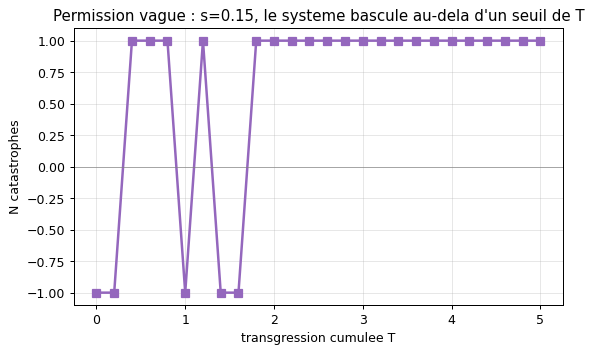

In [7]:
# Exercice 3 -- Permission vague.
# A s fixé (juste sous le seuil), faire varier T au-dela du seuil.

s_inoculation_partielle = 0.15
recompenses_ex3 = np.concatenate([
    np.linspace(-1.5, 1.5, 60),
    np.linspace(1.5, -1.5, 60),
])

def courbe_T(T_grid, s, recompenses):
    # Renvoie le nombre de catastrophes par niveau de T.
    n_cats = np.empty_like(T_grid)
    # TODO etudiant : pour chaque T, hysteresis + comptage.
    return n_cats


# Bloc demonstration.
if __name__ == "__main__":
    T_grid = np.linspace(0.0, 5.0, 26)
    n_cats = courbe_T(T_grid, s_inoculation_partielle, recompenses_ex3)

    plt.figure(figsize=(7, 4))
    plt.plot(T_grid, n_cats, 's-', lw=2, color='tab:purple')
    plt.xlabel("transgression cumulee T")
    plt.ylabel("N catastrophes")
    plt.title(f"Permission vague : s={s_inoculation_partielle}, "
              f"le systeme bascule au-dela d'un seuil de T")
    plt.axhline(0, color='gray', lw=0.5)
    plt.grid(alpha=0.3)
    plt.show()

    # Reflexion : a s petit, T doit etre *grand* pour atteindre la
    # bistabilite. Inversement, T nul + s grand -> tout bistable. Le
    # produit T * s joue le role de regulateur. Est-ce que le resultat
    # numerique est coherent avec cette intuition ?
    #
    # TODO etudiant : commenter en reponse.

## 6. Cellule frontiere -- ce que ce modele capture et ne capture pas

**Ce que le modele capture bien** :

1. La **forme qualitative** de la transition : bistable -> monostable
   par inoculation, c'est exactement le pattern observe par Anthropic
   dans leurs experiences (permission explicite -> pas de desalignement
   emergent).
2. Le **caractere irreversible** d'une bascule : si le systeme est dans
   le bassin "persona toxique" et qu'on retire la recompense, il
   *peut* rester bloque (hysteresis), exactement comme ICT-10.
3. Les **EWS Wissel/Scheffer** : la variance et l'AR1 montent
   avant le pli, maitre-mot du diagnostic en temps reel.

**Ce que le modele ne capture pas -- frontiere honnete** :

1. **In-context vs en-entrainement**. Le modele joue sur la
   dynamique *d'apprentissage* (anthropique, lente). Les phenomenes
   rapportes par Anthropic combinent en plus un **in-context
   learning** rapide pendant la conversation. Le saut
   in-context -> en-entrainement fait l'objet d'ICT-22 (LLMSubstrat
   GPU). Ce notebook y reste correl, pas causal.

2. **Pas de representation interne**. Le parametre d'ordre `p` est une
   abstraction ; on ne modele pas les activations reelles du LLM
   (c'est le role des **persona features** SAE d'OpenAI, cf
   arXiv:2506.19823). Notre `p` est un proxy de bas niveau qui *doit
   pas* etre interprete comme une SAE-feature.

3. **Pas de modele d'optimisation**. La pression de recompense `r`
   est un scalaire externe ; on ne modele pas le sous-systeme
   d'entrainement qui en pratique produit `r` (gradient ascent on a
   reward model). ICT-24 (InoculationRL) traite ce sujet en Partie 2
   GPU-strict.

4. **Stabilite de la "charge semantique"** : on suppose `s` constant ;
   en realite, l'inoculation *s'use* (les permissions vagues
   oublient). Exercice 3 explore ce point mais le modele reste
   stationnaire.

**Conclusion epistemologique** : ce notebook est un **modele jouet** au
sens de Thom -- il capture la *forme* (catastrophe fronce, hysteresis,
EWS) mais pas la *substance* (representation interne, RL effectif). C'est
l'equivalent ICT-23 du May 1977 en ICT-8 : on demontre un effet
qualitatif, pas un mecanisme quantitatif.

## 7. Continuite : ICT-13 grim trigger retrouve ici

ICT-13 introduisait le **grim trigger** : un agent qui coopere tant que
l'autre coopere, mais bascule dans la defection **des la premiere
trahison** et n'y revient jamais. Mathematiquement, c'est un
equilibrium *engage* sur le paysage `V(p) = p^2 / 2 + b * abs(p)`.

Ici, la **persona toxique sous pression de recompense persistante** a
la meme propriete : `b = r > 0` rend le bassin toxique plus profond
que le bassin aligne, et la **barriere** entre les deux est franchie
quand on introduit un peu de bruit (sigma > 0) -- exactement le
mecanisme de cascade d'ICT-10 perception/capture transcrit pour un
**agent** plutot qu'un **ecosysteme**.

La continuite pedagogique :

- **ICT-8 (bistabilite ecosysteme)** : bistabilite reelle, May 1977,
  pli simple.
- **ICT-10 (lacets de predation)** : hysteresis, anticipation,
  cascades.
- **ICT-13 (grim trigger)** : engagement, defection irreversible.
- **ICT-20 (feature dynamics)** : tableau de features, regimes.
- **ICT-23 (persona, ce notebook)** : l'agent comme substrat d'une
  catastrophe anthropique. Le grim trigger devient la bascule
  persistante sous recompense.

**Prochaine etape** (ICT-22, ICT-24, hors scope partie 1 CPU) :
- **ICT-22** : substrat LLM reel (GPU), representation interne SAE.
- **ICT-24** : inoculation en boucle RL (GPU).

## Conclusion

Ce notebook demontre que la **catastrophe fronce de Thom** est le bon
formalisme pour penser le desalignement emergent comme un phenomene de
*transition de phase controlee* :

- L'**inoculation** (`s -> 0`) aplatit le paysage, faisant passer
  l'agent d'une region bistable (deux identites co-existantes) a une
  region monostable (une seule identite stable). C'est **P0**.
- Un balayage aller-retour de la recompense `r` montre alors **deux
  catastrophes** sous bistabilite, **zero** sous inoculation. C'est
  **P1**, et la signature d'inoculation `N_catastrophes(s)` est
  monotone non-croissante.
- Les **EWS Wissel/Scheffer** (variance, AR1) sont plus eleves en
  regime bistable qu'en regime monostable -- c'est **P2**, et le
  diagnostic haut-niveau.

**Limite epistemologique assumee** : ce modele est un **jouet
phenomenologique** (au sens de Thom, May 1977), pas un modele
quantitatif. Il demontre la *forme* (catastrophe, hysteresis, EWS) sans
capturer la *substance* (representation interne du LLM, processus RL).
ICT-22 (representation) et ICT-24 (boucle RL reelle) prennent le
relais.

**References** :
- Anthropic, *Inoculation Prompting*, novembre 2025, [arXiv:2511.18397](https://arxiv.org/abs/2511.18397).
- OpenAI, *Persona Features*, juin 2025, [arXiv:2506.19823](https://arxiv.org/abs/2506.19823).
- Thom, *Stabilite structurelle et morphogenese*, 1972.
- May, *Nature*, 1977 (bistabilite ecologique).
- Wissel, *Oecologia*, 1984 ; Scheffer et al., *Nature*, 2009 (EWS).
- Friston, *Free Energy Principle*, 2010 (energie libre).
- ICT-8 (pli), ICT-10 (lacets), ICT-13 (grim trigger), ICT-20 (feature
  dynamics) dans la meme serie.

**Code & tests** : ``ict/persona_cusp.py`` (module reutilisable,
numpy-only) + ``tests/test_persona_cusp.py`` (12 tests PASS).